# DiffConvNet: Diffusion-Based CNN Framework for DeepFake Detection

**Paper:** *Convolutional neural network framework for deepfake detection: A diffusion-based approach*  
**Authors:** Emmanuel Pintelas, Ioannis E. Livieris  
**Journal:** Computer Vision and Image Understanding 257 (2025) 104375

---

## Overview

This notebook implements the **DiffConvNet** model, which detects DeepFakes by leveraging a diffusion process embedded inside a CNN backbone. The key idea:

1. A pre-trained CNN (ResNet18) is fine-tuned on the deepfake classification task.
2. The CNN is **split** into a Shallow Network (SN) and a Deep Network (DN).
3. A **Diffusion Network (DiffN)** is inserted between SN and DN.
4. The SN encodes the image → DiffN iteratively diffuses the encoding → DN classifies from all diffusion states averaged together.
5. The full **SN-DiffN-DN** pipeline is fine-tuned end-to-end.

The hypothesis: manipulated (fake) images exhibit **unusual, abrupt diffusion patterns**, while real images diffuse smoothly.

---

## Pipeline

```
Input Image
    │
    ▼
Shallow Network (SN)  ──── encodes image to x0
    │
    ▼
Diffusion Network (DiffN)
    x0 → x1 → x2 → ... → xN   (N iterations)
    │
    ▼
Average(x0, x1, ..., xN) = d
    │
    ▼
Deep Network (DN)  ──── extracts features from d → prediction
```

## 1. Install & Import Dependencies

In [ ]:
# Install any missing packages (most are pre-installed on Kaggle)
# !pip install -q timm scikit-learn matplotlib seaborn

import os
# import random
import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from torch.optim import Adam
# from torch.optim.lr_scheduler import ReduceLROnPlateau

# from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# ── Reproducibility ──────────────────────────────────────────────

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

!nvidia-smi
!python -c "import torch; print(torch.__version__); print(torch.version.cuda)"


Using device: cuda
GPU: NVIDIA GeForce RTX 5080
Wed May 13 14:56:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.02              Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080        On  |   00000000:01:00.0  On |                  N/A |
|  0%   51C    P1             49W /  360W |   15704MiB /  16303MiB |      0%      Default |
|                                         |                        |                  N/A |


## 2. Configuration

All hyper-parameters in one place. Adjust `DATA_ROOT` to point to your dataset.

In [3]:
# ── Dataset ──────────────────────────────────────────────────────
# Expected structure:
#   DATA_ROOT/
#       real/   (real face images)
#       fake/   (deepfake face images)
DATA_ROOT = "croped_data/Train"  # <-- change this

# ── Image ────────────────────────────────────────────────────────
IMG_SIZE   = 224          # resize to 256×256 (as in the paper)

# ── Diffusion ────────────────────────────────────────────────────
N_DIFF     = 5            # number of diffusion iterations (paper default)
SPLIT_DEPTH = 1           # where to cut the backbone (Depth 1 is optimal per ablation)

# ── Training ─────────────────────────────────────────────────────
BATCH_SIZE   = 128
WEIGHT_DECAY = 1e-4
LR = 1e-4
PATIENCE_ES  = 10         # early-stopping patience
MAX_EPOCHS   = 50

# ── Phase 1: fine-tune the base network ──────────────────────────
PHASE1_EPOCHS = 5

# ── Phase 2: fine-tune the full DiffConvNet ──────────────────────
PHASE2_EPOCHS = MAX_EPOCHS

print('Configuration loaded.')

Configuration loaded.


## 3. Dataset & DataLoader

A generic `DeepFakeDataset` that reads from `real/` and `fake/` sub-folders.  
Replace with your own dataset class if needed (e.g. DFDC, DFMNIST+, EXP).

In [4]:
# ── Transforms ───────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class DeepFakeDataset(Dataset):
    """
    Expects:
        root/real/*.jpg  (label = 0)
        root/fake/*.jpg  (label = 1)
    """
    EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for label, folder in enumerate(['original', 'deepfake']):
            folder_path = Path(root) / folder
            if not folder_path.exists():
                raise FileNotFoundError(f'Folder not found: {folder_path}')
            for p in sorted(folder_path.iterdir()):
                if p.suffix.lower() in self.EXTS:
                    self.samples.append(p)
                    self.labels.append(label)

        print(f'Dataset loaded: {len(self.samples)} images '
              f'({self.labels.count(0)} original, {self.labels.count(1)} fake)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# ── Demo: create a synthetic dataset if DATA_ROOT doesn't exist ──
def make_demo_dataset(n=200, size=IMG_SIZE):
    """Creates tiny random tensors for smoke-testing the model."""
    class SyntheticDS(Dataset):
        def __init__(self, n, size):
            self.n = n
            self.size = size
            self.labels = [i % 2 for i in range(n)]
        def __len__(self): return self.n
        def __getitem__(self, i):
            img = torch.randn(3, self.size, self.size)
            return img, self.labels[i]
    ds = SyntheticDS(n, size)
    ds.labels = ds.labels  # expose labels for sklearn splitter
    return ds


# USE_DEMO = not Path(DATA_ROOT).exists()
# if USE_DEMO:
#     print('[DEMO MODE] Real data not found - using synthetic random tensors.')
#     full_dataset_train = make_demo_dataset(200)
#     all_labels = full_dataset_train.labels
# else:
#     full_dataset_train = DeepFakeDataset(DATA_ROOT, transform=train_transform)
#     all_labels = full_dataset_train.labels

# print(f'Total samples: {len(full_dataset_train)}')

## 4. Model Architecture

### 4.1 Diffusion Layer

A single 3×3 convolution that propagates (diffuses) the encoded feature map one step.

In [5]:
class DiffLayer(nn.Module):
    """
    One diffusion step: Conv(3×3) + BN + ReLU.
    Input and output have the same shape (channels, H, W).
    Simulates a discrete approximation to a PDE diffusion step.
    """
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels,
                              kernel_size=3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.bn(self.conv(x)))


class DiffusionNetwork(nn.Module):
    """
    Applies DiffLayer N times and returns the averaged representation d.

    Given x0 (from SN), produces:
        x1 = DiffLayer(x0)
        x2 = DiffLayer(x1)
        ...
        xN = DiffLayer(x_{N-1})
        d  = mean(x0, x1, ..., xN)   (Eq. 6 in the paper)
    """
    def __init__(self, channels: int, n_iterations: int):
        super().__init__()
        self.n_iterations = n_iterations
        # One shared DiffLayer (weight-shared across iterations, as in the paper)
        self.diff_layer = DiffLayer(channels)

    def forward(self, x0: torch.Tensor) -> torch.Tensor:
        states = [x0]                        # states = [x0, x1, ..., xN]
        x = x0
        for _ in range(self.n_iterations):
            x = self.diff_layer(x)
            states.append(x)
        # Stack along dim=0 then average → same shape as x0
        d = torch.stack(states, dim=0).mean(dim=0)   # Eq. 6
        return d

### 4.2 Base Network (ResNet18 backbone)

Standard ResNet18 fine-tuned for binary deepfake classification.

In [6]:
class BaseNetwork(nn.Module):
    """
    ResNet18 backbone fine-tuned for binary deepfake detection.
    Exposes each Layer block for later splitting.
    """
    def __init__(self, pretrained: bool = True):
        super().__init__()
        backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)

        # Named layers matching Table 1 in the paper
        self.layer0 = nn.Sequential(
            backbone.conv1, backbone.bn1,
            backbone.relu, backbone.maxpool
        )                                  # 3×H×W  → 64×(H/4)×(W/4)
        self.layer1 = backbone.layer1      # 64 → 64
        self.layer2 = backbone.layer2      # 64 → 128
        self.layer3 = backbone.layer3      # 128 → 256
        self.layer4 = backbone.layer4      # 256 → 512
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(512, 1)    # binary output

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).flatten(1)
        return self.fc(x).squeeze(1)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Return x0 = output of SN (Layer0)."""
        return self.layer0(x)

### 4.3 DiffConvNet (Full Model)

The complete SN → DiffN → DN pipeline (Table 2 in the paper).

In [7]:
class DiffConvNet(nn.Module):
    """
    DiffConvNet = SN + DiffN + DN  (Eq. 3 in the paper)

    Architecture (ResNet18, Depth-1 split, N diffusion iterations):
        SN  : Layer0             (3×H×W → 64×H/4×W/4)
        DiffN: DiffusionNetwork  (64 → 64, averaged over N steps)
        DN  : Layer1–4 + GAP + FC (64 → 1)
    """
    def __init__(self, base_net: BaseNetwork, n_iterations: int = 5):
        super().__init__()
        # ── Shallow Network ──────────────────────────────────────
        self.sn = base_net.layer0           # encodes image → x0

        # ── Diffusion Network ────────────────────────────────────
        # SN outputs 64 channels (from ResNet18 Layer0)
        self.diff_net = DiffusionNetwork(channels=64,
                                         n_iterations=n_iterations)

        # ── Deep Network ─────────────────────────────────────────
        self.dn_layer1 = base_net.layer1
        self.dn_layer2 = base_net.layer2
        self.dn_layer3 = base_net.layer3
        self.dn_layer4 = base_net.layer4
        self.dn_gap    = base_net.gap
        self.dn_fc     = base_net.fc

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Step 4 – encode image to x0
        x0 = self.sn(x)

        # Steps 5–6 – diffuse and average → d
        d = self.diff_net(x0)

        # Step 7 – deep network classifies from d
        out = self.dn_layer1(d)
        out = self.dn_layer2(out)
        out = self.dn_layer3(out)
        out = self.dn_layer4(out)
        out = self.dn_gap(out).flatten(1)
        return self.dn_fc(out).squeeze(1)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Quick sanity check
bn_test  = BaseNetwork(pretrained=False)
dcn_test = DiffConvNet(bn_test, n_iterations=N_DIFF)
dummy    = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
out_test = dcn_test(dummy)
print(f'DiffConvNet output shape : {out_test.shape}  (expected: [2])')
print(f'DiffConvNet parameters   : {count_params(dcn_test):,}')

DiffConvNet output shape : torch.Size([2])  (expected: [2])
DiffConvNet parameters   : 11,214,017


## 5. Training Utilities

Helpers for one epoch of training / validation, the geometric mean metric, and early stopping.

In [8]:
# ── Geometric Mean (GM) ──────────────────────────────────────────
def geometric_mean(y_true, y_pred_binary):
    """GM = sqrt(sensitivity X specificity)"""
    cm   = confusion_matrix(y_true, y_pred_binary)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        return np.sqrt(sens * spec)
    return 0.0


# ── One training epoch ───────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        preds      = (torch.sigmoid(logits) >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += len(labels)
    return total_loss / total, 100.0 * correct / total


# ── One validation epoch ─────────────────────────────────────────
@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_probs = [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        probs  = torch.sigmoid(logits)
        total_loss += loss.item() * len(labels)
        preds      = (probs >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += len(labels)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    acc  = 100.0 * correct / total
    loss = total_loss / total
    auc  = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5
    gm   = geometric_mean(np.array(all_labels),
                          (np.array(all_probs) >= 0.5).astype(int))
    return loss, acc, auc, gm, np.array(all_labels), np.array(all_probs)


# ── Early Stopping ───────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience: int = 10, mode: str = 'max', delta: float = 1e-4):
        self.patience  = patience
        self.mode      = mode
        self.delta     = delta
        self.best      = -np.inf if mode == 'max' else np.inf
        self.counter   = 0
        self.best_state = None

    def __call__(self, metric, model):
        improved = (self.mode == 'max' and metric > self.best + self.delta) or \
                   (self.mode == 'min' and metric < self.best - self.delta)
        if improved:
            self.best       = metric
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience   # True → stop

print('Training utilities defined.')

Training utilities defined.


## 6. Phase 1 – Fine-tune the Base Network (Algorithm 1, Step 1)

Before inserting the diffusion network, we fine-tune the ResNet18 backbone on the deepfake classification loss.  
This ensures the SN will produce a meaningful encoded representation x0.

In [9]:
def train_base_network(train_loader, val_loader, epochs=PHASE1_EPOCHS,
                       device=DEVICE, pretrained=True):
    """
    Step 1 of Algorithm 1: Fine-tune BN w.r.t. DeepFake classification loss.
    Returns the trained BaseNetwork.
    """
    print('\n=== PHASE 1: Fine-tuning Base Network ===')
    model     = BaseNetwork(pretrained=pretrained)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs!")
        model = torch.nn.DataParallel(model)
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.3)

    CKPT_DIR       = "checkpoints"
    os.makedirs(CKPT_DIR, exist_ok=True)
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    PATIENCE = PATIENCE_ES
    best_epoch = 0

    history = {'train_loss': [], 'val_acc': [], 'val_auc': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, vl_auc, vl_gm, _, _ = eval_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)

        if epoch % 3 == 0:
            ckpt_path = os.path.join(CKPT_DIR, f"base_net_epoch{epoch:03d}.pth")
            torch.save(model.state_dict(), ckpt_path)

        if vl_loss < best_val_loss: # Early stopping logic based on loss like in kaustubh
            best_val_loss = vl_loss
            best_epoch = epoch
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), "base_net_best.pth")
        else:
            patience_counter += 1

        improved_marker = " best" if patience_counter == 0 else f" (patience {patience_counter}/{PATIENCE})"
        print(f'  Epoch {epoch:3d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.1f}% | '
              f'Val   Loss: {vl_loss:.4f} Acc: {vl_acc:.1f}% '
              f'AUC: {vl_auc:.4f} GM: {vl_gm:.4f}' + improved_marker)

        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break

    # Restore best weights
    if 'best_state' in locals():
        model.load_state_dict(best_state)
    return model, history

print('Phase 1 training function defined.')

Phase 1 training function defined.


## 7. Phase 2 – Build & Fine-tune DiffConvNet (Algorithm 1, Steps 2–8)

After phase 1:
1. Split BN → SN + DN (at Depth 1)
2. Attach DiffN between SN and DN
3. Fine-tune the entire SN-DiffN-DN end-to-end

In [10]:
import os
def build_and_train_diffconvnet(base_net, train_loader, val_loader,
                                 n_diff=N_DIFF, epochs=PHASE2_EPOCHS,
                                 device=DEVICE):
    """
    Steps 2-8 of Algorithm 1:
      - Build DiffConvNet from the fine-tuned BN
      - Fine-tune end-to-end w.r.t. DeepFake classification loss
    Returns the trained DiffConvNet.
    """
    print('\n=== PHASE 2: Fine-tuning DiffConvNet end-to-end ===')

    # Use .module if the prev model was wrapped in DataParallel
    if hasattr(base_net, 'module'):
        base_net = base_net.module

    # Steps 2 & 3: split BN and attach DiffN
    model = DiffConvNet(base_net, n_iterations=n_diff)
    if torch.cuda.device_count() > 1:
         print(f"Using {torch.cuda.device_count()} GPUs!")
         model = torch.nn.DataParallel(model)
    model = model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.3)
    
    CKPT_DIR       = "checkpoints"
    os.makedirs(CKPT_DIR, exist_ok=True)
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    PATIENCE = PATIENCE_ES
    best_epoch = 0

    history = {'train_loss': [], 'val_acc': [], 'val_auc': [], 'val_gm': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, vl_auc, vl_gm, _, _ = eval_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['val_gm'].append(vl_gm)

        if epoch % 3 == 0:
            ckpt_path = os.path.join(CKPT_DIR, f"diffconvnet_epoch{epoch:03d}.pth")
            torch.save(model.state_dict(), ckpt_path)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_epoch = epoch
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), "diffconvnet_best.pth")
        else:
            patience_counter += 1

        improved_marker = " best" if patience_counter == 0 else f" (patience {patience_counter}/{PATIENCE})"
        print(f'  Epoch {epoch:3d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.1f}% | '
              f'Val   Loss: {vl_loss:.4f} Acc: {vl_acc:.1f}% '
              f'AUC: {vl_auc:.4f} GM: {vl_gm:.4f}' + improved_marker)

        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break

    if 'best_state' in locals():
        model.load_state_dict(best_state)
    return model, history

print('Phase 2 training function defined.')

Phase 2 training function defined.


## Train model

In [ ]:
# from torch.utils.data import DataLoader, random_split

TRAIN_DIR = "croped_data/Train"
VAL_DIR = "croped_data/Validation"
print(f"Loading dataset from...")


# Create separate dataset instances to properly apply train vs val transforms

train_full = DeepFakeDataset(TRAIN_DIR, transform=train_transform)
val_full   = DeepFakeDataset(VAL_DIR, transform=val_transform)
    
# # Perform splits using random permutations
# indices = torch.randperm(len(train_full)).tolist()
# val_size = int(0.15 * len(train_full))
    
# train_ds = torch.utils.data.Subset(train_full, indices[val_size:])
# val_ds   = torch.utils.data.Subset(val_full, indices[:val_size])

print(f"Train size: {len(train_full)}, Val size: {len(val_full)}")

train_loader = DataLoader(train_full, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_full,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


# ── Phase 1: Train Base Network ───────────────────────────────────────
base_net, base_history = train_base_network(
    train_loader, val_loader, epochs=PHASE1_EPOCHS, device=device
)

# ── Phase 2: Train DiffConvNet ────────────────────────────────────────
diff_net, diff_history = build_and_train_diffconvnet(
    base_net, train_loader, val_loader, n_diff=N_DIFF, epochs=PHASE2_EPOCHS, device=device
)

# ── Save final model ──────────────────────────────────────────────────
torch.save(diff_net.state_dict(), "diffconvnet_final.pth")
print("\nFinal DiffConvNet model saved  → diffconvnet_final.pth")
print("Best DiffConvNet model saved   → diffconvnet_best.pth")

## 9. Run the prediction


In [20]:
def predict_fake_image(image_path, model_class, transform, model_path="diffconvnet_final.pth", device=None):
    """
    Predict whether an image is Real or Fake using your trained DiffConvNet.
    
    Args:
        image_path (str): Path to the input image
        model_class (torch.nn.Module): Your model class (e.g., DiffConvNet)
        transform (torchvision.transforms): The exact same transform used during validation
        model_path (str): Path to saved state_dict
        device (torch.device): Optional device override
        
    Returns:
        dict: {"prediction": int, "confidence": float, "probabilities": np.array}
    """
    # 1. Set device
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 2. Load model architecture
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
        
    model = model_class()
    # weights_only=True is recommended for PyTorch >= 2.0
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()  # Crucial for dropout/batchnorm behavior
    
    # 3. Load & preprocess image (must match validation transform exactly)
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
        
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)  # Shape: (1, C, H, W)
    
    # 4. Inference
    with torch.no_grad():
        logits = model(img_tensor)
        
        # 🔹 OPTION A: If your model outputs 2 classes (softmax + CrossEntropy)
        # probs = torch.softmax(logits, dim=1)
        # pred_class = torch.argmax(probs, dim=1).item()
        # confidence = probs[0, pred_class].item()
        
        # 🔹 OPTION B: If your model outputs 1 class (sigmoid + BCEWithLogits)
        probs = torch.sigmoid(logits)
        pred_class = (probs > 0.5).int().item()
        confidence = probs.item()
        
    return {
        "prediction": pred_class,      # 0 = Real, 1 = Fake (adjust to your label mapping)
        "confidence": confidence,      # Probability of predicted class
        "probabilities": probs.cpu().numpy()
    }


predict_fake_image(
    image_path="00024.png", 
    model_class=lambda: DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF), 
    transform=val_transform,
    model_path="diffconvnet_best.pth"
)

{'prediction': 0,
 'confidence': 0.031091654673218727,
 'probabilities': array([0.03109165], dtype=float32)}

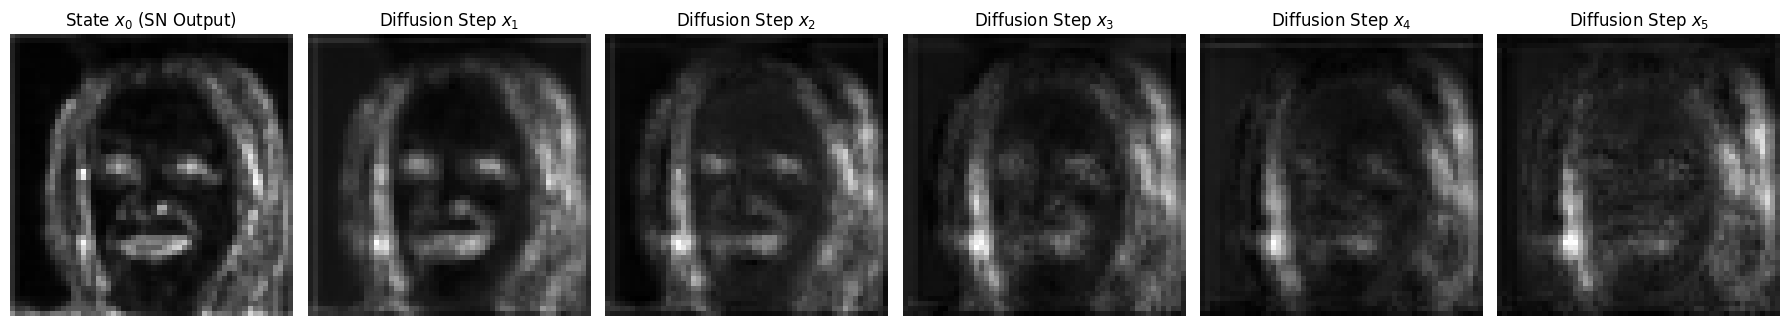

In [ ]:
import matplotlib.pyplot as plt

def visualize_diffusion_states(image_path, model_path="diffconvnet_best.pth", device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    # 1. Load the trained model
    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()
    
    # 2. Load and transform the image
    img = Image.open(image_path).convert("RGB")
    img_tensor = val_transform(img).unsqueeze(0).to(device)
    
    # 3. Extract the diffusion states manually
    with torch.no_grad():
        # Encode image to x0 (Output of Shallow Network)
        x = model.sn(img_tensor)
        states = [x]
        
        # Iteratively apply the Diffusion Layer
        for _ in range(model.diff_net.n_iterations):
            x = model.diff_net.diff_layer(x)
            states.append(x)
            
        # Compute the final averaged state 'd' exactly like the model does
        d = torch.stack(states, dim=0).mean(dim=0)
            
    # 4. Plot the states + the average
    num_plots = len(states) + 1
    fig, axes = plt.subplots(1, num_plots, figsize=(3 * num_plots, 4))
    
    # Plot individual states
    for i, state in enumerate(states):
        feature_map = state.squeeze(0).mean(dim=0).cpu().numpy()
        
        axes[i].imshow(feature_map, cmap='gray')
        if i == 0:
            axes[i].set_title(f"State $x_0$ (SN Output)")
        else:
            axes[i].set_title(f"Diffusion Step $x_{i}$")
        axes[i].axis('off')
        
    # Plot the averaged state
    d_map = d.squeeze(0).mean(dim=0).cpu().numpy()
    axes[-1].imshow(d_map, cmap='gray')
    axes[-1].set_title("Averaged State $d$")
    axes[-1].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the visualization on your image
visualize_diffusion_states("00024.png")

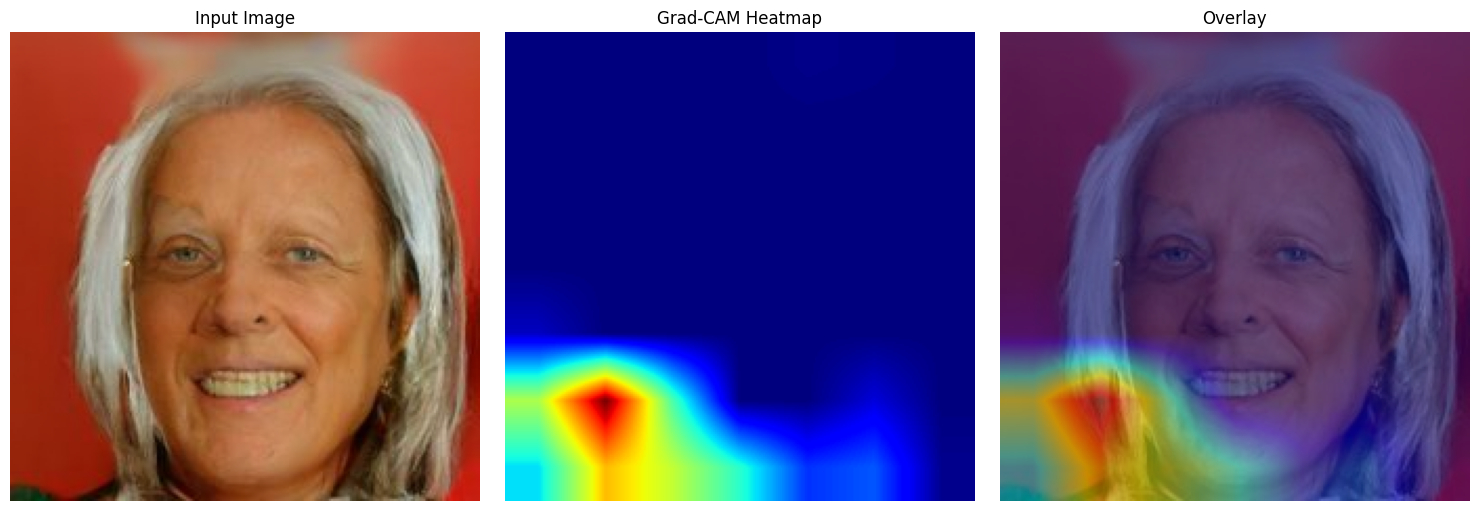

In [24]:
import cv2  # Make sure opencv is installed: !pip install opencv-python-headless
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks to extract feature maps and gradients
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):
        self.model.eval()
        self.model.zero_grad()
        
        # Forward pass
        logits = self.model(x)
        
        # For binary classification with a single output (BCEWithLogitsLoss),
        # we can backpropagate the raw logit directly.
        loss = logits[0]
        loss.backward()
        
        # Get pooled gradients
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        # Global average pool the gradients
        weights = np.mean(gradients, axis=(1, 2))
        
        # Compute the weighted sum of feature maps
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        # Apply ReLU to only keep features with positive influence on the class
        cam = np.maximum(cam, 0)
        
        # Normalize between 0 and 1
        if np.max(cam) != 0:
            cam = cam / np.max(cam)
        return cam

def generate_gradcam_plot(image_path, model_path="diffconvnet_best.pth", device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    # 1. Load Model
    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    
    # 2. Target the final spatial layer before pooling
    target_layer = model.dn_layer4
    grad_cam = GradCAM(model, target_layer)
    
    # 3. Load & preprocess Image
    original_img = Image.open(image_path).convert("RGB")
    original_resized = original_img.resize((IMG_SIZE, IMG_SIZE))  # 224x224
    img_tensor = val_transform(original_img).unsqueeze(0).to(device)
    
    # 4. Generate CAM
    cam = grad_cam(img_tensor)
    
    # 5. Create Heatmap and Overlay
    # Resize CAM to image shape
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    
    # Convert CAM to colored heatmap using OpenCV
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    original_arr = np.array(original_resized)
    
    # Blend image and heatmap
    alpha = 0.5
    overlay = (original_arr * alpha + heatmap * (1 - alpha)).astype(np.uint8)
    
    # 6. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original_arr)
    axes[0].set_title("Input Image")
    axes[0].axis("off")
    
    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")
    
    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

# Run it on your test image
generate_gradcam_plot("00024.png")

### 10.2 Confusion Matrix (last fold)

### 10.3 Diffusion States Visualisation

Replicates Figure 4 from the paper: shows the transient states of the diffusion network for a real and a fake image.

antingen grad cam som ger dig färg som fig 3

eller gråskaling som fig 4

## 13. Grad-CAM Interpretability

Replicates Figure 3 from the paper: Grad-CAM visualisation showing which facial regions the model focuses on when making predictions.